# $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$ MPS optimization - Manual fixed point check

Created: 23-07-2026

Objectives:
* Apply methods of [this notebook](z2_f_x_z2_t_mps_optimization.ipynb) to state manually prepared as in [this notebook](z2_f_x_z2_t_obc_fixed_point_check.ipynb).

# Imports

In [1]:
import numpy as np
import pandas as pd

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [110]:
from functools import reduce
from operator import mul
from itertools import product
from collections import Counter

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d, tensor_basis

In [8]:
from time import time

In [9]:
from humanize import naturalsize

In [10]:
import pickle

In [11]:
TOP_DATA_DIR = r"../../data/"
TRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_triv_to_nontriv_n1_10_site_ed"
NONTRIV_COCYCLE_DIR = TOP_DATA_DIR + r"z2_f_x_z2_t_nontriv_n1_to_nontriv_cocyle_10_site_ed"

# Prepare $(n_1, \nu_2) = (1,1)$ state

In [222]:
X = np.zeros((2,)*20)

In [223]:
a = np.array([0,0,1,1])

In [224]:
for b in product([0,1], repeat=10):
    b = np.array(b)
    b_forward = np.roll(b, -1)

    fermion_decoration = np.bitwise_xor(b, b_forward)

    index = np.empty((b.size + fermion_decoration.size,), dtype=a.dtype)
    index[0::2] = b
    index[1::2] = fermion_decoration

    X[*index] = 1/np.pow(2, 10/2)

In [225]:
np.sum(X * X.conj())

np.float64(1.0)

In [226]:
np_change_to_Y_basis = (1/np.sqrt(2))*np.array([
    [1, 1],
    [1j, -1j]
])

In [227]:
qu_change_to_Y_basis = qtn.Tensor(
    np_change_to_Y_basis,
    inds=['k', 'b']
)

In [228]:
manual_qt_psi_Z_basis = qtn.Tensor(
    X,
    inds=[f'k{i}' for i in range(20)]
)

In [229]:
Counter(np.round(manual_qt_psi_Z_basis.data.flatten(), 6))

Counter({np.float64(0.0): 1047552, np.float64(0.03125): 1024})

In [21]:
qt_periodic_psi_y_basis = qtn.TensorNetwork(
    [manual_qt_psi_Z_basis.reindex({f'k{i}': f'b{i}' for i in range(0, 20, 2)})]
    + [qu_change_to_Y_basis.reindex({'k': f'k{i}', 'b': f'b{i}'}) for i in range(0, 20, 2)]
)

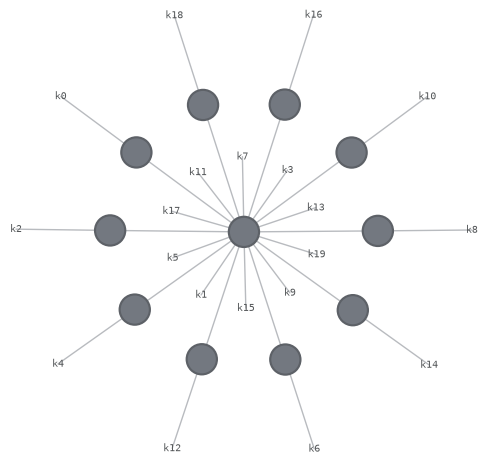

In [22]:
qt_periodic_psi_y_basis.draw()

In [23]:
qt_periodic_psi_y_basis.contract(inplace=True)

TensorNetwork(tensors=1, indices=20)

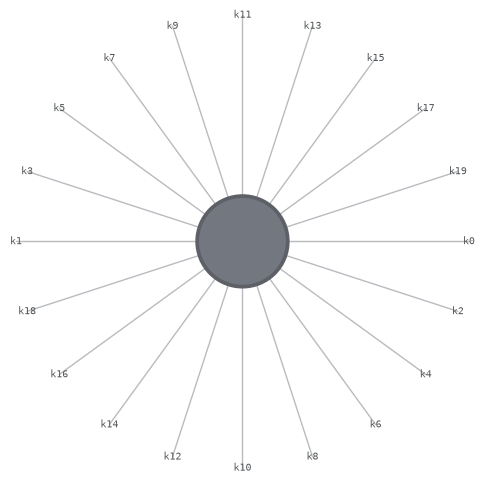

In [24]:
qt_periodic_psi_y_basis.draw()

# Definitions

In [25]:
L = 10

In [26]:
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [27]:
np_I = np.array([
    [1,0],
    [0,1]
])

np_Z = np.array([
    [1,0],
    [0,-1]
])

In [28]:
# Fermion parity on fermion sites
qu_FP = qtn.Tensor(np_Z, inds=['k', 'b'])

In [29]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [30]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [31]:
def get_multisite_qu_FP(sites):
    # Assuming fermion sites are on odd sites
    arrays = [
        (np_Z if (i%2) else np_I)
        for i in sites
    ]

    np_multisite_FP = multikron(arrays)

    out = qtn.Tensor(
        np_multisite_FP,
        inds=['k', 'b'],
        tags='multisite_FP',
    )

    return out

## Defect operators

In [32]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [33]:
def normalize_A(A):
    # Ensure trace = 1
    trace = jnp.real((A & A.conj()).contract())
    A = A.multiply(trace**(-0.5), spread_over=A.num_tensors)

    # Equalize norms
    norms = [
        jnp.sqrt(jnp.real((a & a.conj()).contract()))
        for a in A.tensors
    ]
    geometric_mean_norms = jnp.pow(reduce(mul, norms), 1/(A.num_tensors))

    for a, norm in zip(A.tensors, norms):
        a.modify(data=a.data*geometric_mean_norms/norm)

    return A

In [34]:
alternative_vertical_index_dict = {
    'vLV': 'vLV_alt',
    'vRV': 'vRV_alt'
}

In [35]:
def get_rho_A_purity(A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A
    t2 = A.conj().reindex(transpose_dict)
    t3 = A.reindex(transpose_dict | alternative_vertical_index_dict)
    t4 = A.conj().reindex(alternative_vertical_index_dict)

    t = (t1 & t2 & t3 & t4)

    return jnp.real(t.contract())

In [36]:
def get_rho_A_rho_overlap(rho, A):
    # A regex would be much more robust here
    k_inds = [
        int(ind[1:]) for ind in A.outer_inds()
        if ind[0] == 'k'
    ]

    transpose_dict = {f'k{i}': f'b{i}' for i in k_inds}
    t1 = A.reindex(transpose_dict)
    t2 = A.conj()

    t = (rho & t1 & t2)

    return jnp.real(t.contract())

In [37]:
def loss_func(A, rho, rho_purity):

    out = jnp.real(
        rho_purity
        + get_rho_A_purity(A)
        -2*get_rho_A_rho_overlap(rho, A)
    )

    return out

In [38]:
def get_initial_rho_mps_representation(domains_dict):
    symmetry_sites = domains_dict['symmetry_sites']
    horizontal_bond_dimension = domains_dict['mps_horizontal_bond_dimension']
    vertical_bond_dimension = domains_dict['mps_vertical_bond_dimension']

    i = symmetry_sites[0]
    leftmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            vertical_bond_dimension,
            2,
            horizontal_bond_dimension
        )),
        inds=('vLV', f'k{i}', f'vH{i}')
    )

    interior_mps_tensors = [
        qtn.Tensor(
            data=random_uniform_complex((
                horizontal_bond_dimension,
                2,
                horizontal_bond_dimension
            )),
            inds=(f'vH{i-1}', f'k{i}', f'vH{i}')
        )
        for i in symmetry_sites[1:-1]
    ]

    i = symmetry_sites[-1]
    rightmost_mps_tensor = qtn.Tensor(
        data=random_uniform_complex((
            horizontal_bond_dimension,
            2,
            vertical_bond_dimension
        )),
        inds=(f'vH{i-1}', f'k{i}', 'vRV')
    )

    mps_tensors = [
        leftmost_mps_tensor,
        *interior_mps_tensors,
        rightmost_mps_tensor
    ]
    
    A = qtn.TensorNetwork(mps_tensors)

    return A

In [39]:
def get_rho_mps_representation(qt_rho, rho_purity, domains_dict):
    A = get_initial_rho_mps_representation(domains_dict)

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=500)

    tnopt = qtn.TNOptimizer(
        A_opt,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="adam",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=500)

    return A_opt, tnopt.losses, tnopt.loss_best

In [40]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl, kr, bl, br]
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl'), edm.ind_size('kl')),
        inds=['kl', 'bl'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br'), edm.ind_size('kr')),
        inds=['kr', 'br'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl': 'bl', 'bl':'kl'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr', 'br'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr': 'br', 'br':'kr'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl', 'bl'])

    return (left_defect_op, right_defect_op), scores

In [41]:
def get_rho_tilde(mps_decomp, domains_dict):
    # rho_tilde is a reduced density matrix with the bra part complex conjugated
    A = mps_decomp

    # Left side
    A_l = A.tensors[next(iter(A.ind_map['vLV']))]
    k_left_ind = min(domains_dict['symmetry_sites'])
    dummy_left_index = f'vH{k_left_ind}'
    
    tn_l = (
        A_l
        &
        A_l.conj().reindex({
            f'k{k_left_ind}': f'b{k_left_ind}',
            dummy_left_index: 'dl',
        })
    )
    tn_l = tn_l.contract()

    left_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=[f'k{k_left_ind}', dummy_left_index],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    # Right side
    A_r = A.tensors[next(iter(A.ind_map['vRV']))]
    k_right_ind = max(domains_dict['symmetry_sites'])
    dummy_right_index = f'vH{k_right_ind-1}'

    tn_r = (
        A_r
        &
        A_r.conj().reindex({
            f'k{k_right_ind}': f'b{k_right_ind}',
            dummy_right_index: 'dr',
        })
    )
    tn_r = tn_r.contract()

    right_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=[f'k{k_right_ind}', dummy_right_index],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    ket_tensors = [
        *left_decomp.tensors[:-1],
        *[t for t in mps_decomp.tensors[1:-1]],
        *right_decomp.tensors[:-1]
    ]

    bra_tensors = [
        left_decomp.tensors[-1].conj().reindex({'dl': dummy_left_index}),
        *[
            t.reindex({f'k{i}': f'b{i}'})
            for t, i in zip(mps_decomp.tensors[1:-1], domains_dict['symmetry_sites'][1:-1])
        ],
        right_decomp.tensors[-1].conj().reindex({'dr': dummy_right_index})
    ]

    ket_tn = qtn.TensorNetwork(ket_tensors)
    bra_tn = qtn.TensorNetwork(bra_tensors).mangle_inner_()

    rho_tilde = ket_tn & bra_tn

    return rho_tilde

In [42]:
def get_edm_from_rho_tilde(rho_tilde, domains_dict):
    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )
    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    output_inds = sum(fuse_map.values(), [])

    edm = (
        rho_tilde.reindex({f'b{i}': f'k{i}' for i in central_sites})
        .contract(output_inds=output_inds)
        .fuse(fuse_map)
    )

    return edm

In [43]:
def get_defect_ops_and_indices_from_mps_decomposition(
    qt_rho, mps_decomp, domains_dict):

    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    rho_tilde = get_rho_tilde(mps_decomp, domains_dict)

    edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl', 'bl'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    not_left_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['left_defect_sites']
    ]

    rho_defect_l = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_left_defect_sites})
        .contract()
        .fuse(left_fuse_map)
    )

    left_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['left_defect_sites']
    )

    left_defect_op_n1_invariant = (
        rho_defect_l
        & left_defect_qu_FP.reindex({'b': 'kl', 'k': 'ki1'})
        & left_defect_operator.reindex({'bl': 'ki1', 'kl': 'ki2'}) 
        & left_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & left_defect_operator.conj().reindex({'kl': 'ki3', 'bl': 'bl'}) 
    )
    left_defect_op_n1_invariant=left_defect_op_n1_invariant.contract()

    left_defect_op_cocycle_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl': 'kl', 'kl': 'ki1'})
        & left_defect_operator.conj().reindex({'bl': 'ki1', 'kl': 'bl'})
    )
    left_defect_op_cocycle_invariant=left_defect_op_cocycle_invariant.contract()

    not_right_defect_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in domains_dict['right_defect_sites']
    ]

    rho_defect_r = (
        qt_rho
        .reindex({f'k{i}': f'b{i}' for i in not_right_defect_sites})
        .contract()
        .fuse(right_fuse_map)
    )

    right_defect_qu_FP = get_multisite_qu_FP(
        domains_dict['right_defect_sites']
    )

    right_defect_op_n1_invariant = (
        rho_defect_r
        & right_defect_qu_FP.reindex({'b': 'kr', 'k': 'ki1'})
        & right_defect_operator.reindex({'br': 'ki1', 'kr': 'ki2'}) 
        & right_defect_qu_FP.reindex({'b': 'ki2', 'k': 'ki3'})
        & right_defect_operator.conj().reindex({'kr': 'ki3', 'br': 'br'}) 
    )
    right_defect_op_n1_invariant=right_defect_op_n1_invariant.contract()

    right_defect_op_cocycle_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br': 'kr', 'kr': 'ki1'})
        & right_defect_operator.conj().reindex({'br': 'ki1', 'kr': 'br'})
    )
    right_defect_op_cocycle_invariant=right_defect_op_cocycle_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl': 'bl', 'bl': 'kl'})
        & right_defect_operator.reindex({'kr': 'br', 'br': 'kr'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_operator,
        right_defect_operator,
        left_defect_op_n1_invariant,
        right_defect_op_n1_invariant,
        left_defect_op_cocycle_invariant,
        right_defect_op_cocycle_invariant,
        overlaps,
        overlap
    )

    return out

In [44]:
def get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    shape_map = {
        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
        'kr': (right_defect_complement_op_dim, right_defect_op_dim),
        'bl': (left_defect_op_dim, left_defect_complement_op_dim),
        'br': (right_defect_complement_op_dim, right_defect_op_dim)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [45]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    #rho.contract(inplace=True)

    return rho

In [46]:
def get_purity_from_quimb_rdm(rdm):
    rdm_indices = rdm.outer_inds()

    k_indices = [s for s in rdm_indices if s.startswith('k')]
    b_indices = [s for s in rdm_indices if s.startswith('b')]

    rdm_transpose_map = {
        **{s: f'b{s[1:]}' for s in k_indices},
        **{s: f'k{s[1:]}' for s in b_indices}
    }

    out = (
        rdm
        & rdm.reindex(rdm_transpose_map)
    )
    out.contract(inplace=True)
    out = np.real(out.item())

    return out

# Check symmetries

## $Z$ symmetries

In [84]:
np_Z = np.array([
    [1,0],
    [0,-1]
])
qu_Z = qtn.Tensor(np_Z, inds=['k', 'b'])

In [85]:
qt_psi = qt_periodic_psi_y_basis

In [88]:
sym_gates = [
    qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
    for i in range(0, 20, 2)
]

In [90]:
sym_qt_psi = qtn.TensorNetwork(
    [qt_psi.reindex({f'k{i}': f'b{i}' for i in range(0, 20, 2)}),]
    + sym_gates
)

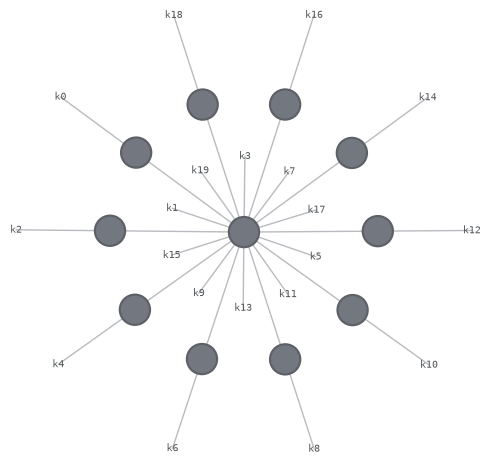

In [91]:
sym_qt_psi.draw()

In [92]:
sym_qt_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=20)

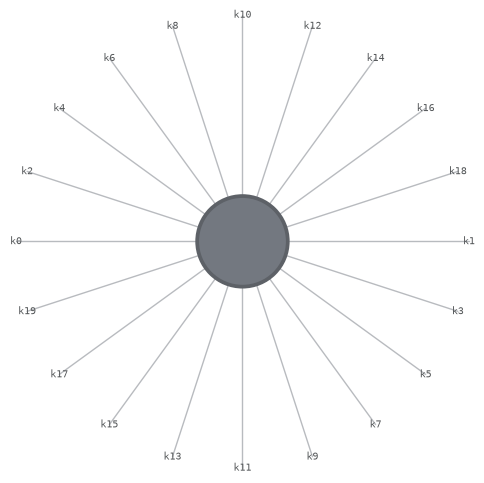

In [93]:
sym_qt_psi.draw()

In [94]:
(sym_qt_psi & sym_qt_psi.conj()).contract()

np.complex128(0.9999999999999999+0j)

In [95]:
np.abs((qt_psi & sym_qt_psi.conj()).contract())

np.float64(0.9999999999999999)

It's a symmetry.

## $K$ symmetry

In [98]:
np.abs((qt_psi & qt_psi).contract())

np.float64(0.9999999999999999)

Also a symmetry. 

# Find defect operators

In [47]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(2, 16)),
    'left_defect_sites': [2, 3, 4, 5],
    'right_defect_sites': [12, 13, 14, 15],
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [48]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

In [49]:
qt_psi = qt_periodic_psi_y_basis

rho = get_rdm_from_quimb_psi(qt_psi, domains_dict['symmetry_sites'])
rho_purity = get_purity_from_quimb_rdm(rho)
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(


## Analyze results

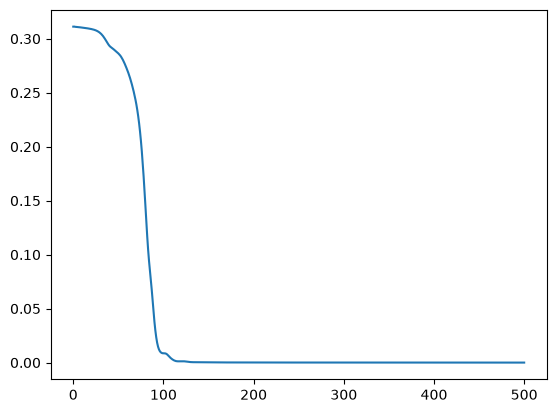

In [50]:
plt.plot(opt_out[1])

In [51]:
opt_out[1][-1]

1.850724220275879e-05

In [53]:
defect_opt_out[0][:5]

array([2.4794734e-01, 2.2725482e-05, 8.3882178e-06, 1.7542045e-06,
       2.2472567e-07], dtype=float32)

In [54]:
defect_opt_out[3], defect_opt_out[4]

(np.complex128(-0.7772868763641843+0j),
 np.complex128(-0.323598412860567+1.3877787807814457e-17j))

Oh..., so there is definitely a $n_1$ problem with MPS factorization? Strange.

In [55]:
defect_opt_out[5], defect_opt_out[6]

(np.complex128(0.999999998383072+1.0916323400778083e-10j),
 np.complex128(1.0000000260900572-2.9949276392216007e-10j))

But at least $\omega$ is correct...

In [56]:
defect_opt_out[-1]

np.float32(0.9949645)

# Find defect operators - single defect site

In [57]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(7, 14)),
    'left_defect_sites': [7,],
    'right_defect_sites': [13,],
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [58]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

In [59]:
qt_psi = qt_periodic_psi_y_basis

rho = get_rdm_from_quimb_psi(qt_psi, domains_dict['symmetry_sites'])
rho_purity = get_purity_from_quimb_rdm(rho)
opt_out = get_rho_mps_representation(rho, rho_purity, domains_dict)
defect_opt_out = get_defect_ops_and_indices_from_mps_decomposition(rho, opt_out[0], domains_dict)

E0723 11:31:19.845171   19075 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %dot.52 = c64[128,128]{1,0} dot(%constant.1, %constant.3), lhs_contracting_dims={1}, rhs_contracting_dims={0}, metadata={op_name="jit(MakeArrayFn)/jvp()/dot_general" stack_frame_id=161}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0723 11:31:20.426572   19049 slow_operation_alarm.cc:140] The operation took 1.581990537s
Constant folding an instruction is taking > 1s:

  %dot.52 = c64[128,128]{1,0} dot(%constant.1, %constant.3), lhs_contracting_dims={1}, rhs_contracting_dims={0}, metadata={op_name="jit(MakeArrayFn)/jvp()/dot_gener

## Analyze results

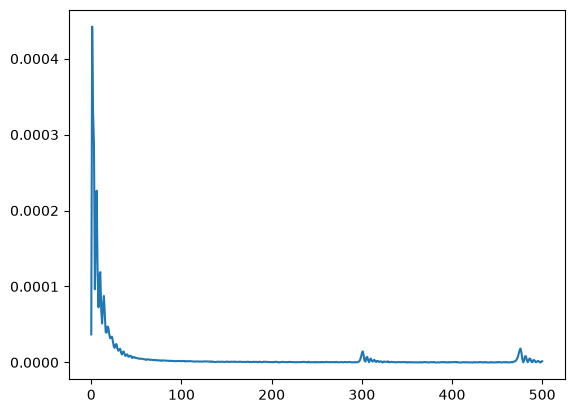

In [60]:
plt.plot(opt_out[1])

In [61]:
opt_out[1][-1]

1.6093254089355469e-06

In [62]:
defect_opt_out[0][:5]

array([4.9958572e-01, 2.4021605e-07, 3.4759289e-08, 1.2791266e-08],
      dtype=float32)

In [68]:
np.round(defect_opt_out[1].data, 3)

array([[0.043-0.014j, 0.312+0.949j],
       [0.312+0.949j, 0.043-0.014j]], dtype=complex64)

Definitely not fermion parity definite. Am I doing something weird with $E$?

In [69]:
np.round(defect_opt_out[2].data, 3)

array([[ 0.376+0.763j, -0.472+0.233j],
       [-0.472+0.233j,  0.376+0.763j]], dtype=complex64)

In [63]:
defect_opt_out[3], defect_opt_out[4]

(np.complex128(-0.9959584695612375+0j), np.complex128(0.44657812915185213+0j))

In [64]:
defect_opt_out[5], defect_opt_out[6]

(np.complex128(0.9999999805417676+0j), np.complex128(1.0000000092692143+0j))

But at least $\omega$ is correct...

In [65]:
defect_opt_out[-1]

np.float32(0.99917126)

In [70]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)

central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

left_fuse_map = {
    'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
    'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
}
right_fuse_map = {
    'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
    'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
}
fuse_map = left_fuse_map | right_fuse_map

rho_tilde = get_rho_tilde(opt_out[0], domains_dict)

edm = get_edm_from_rho_tilde(rho_tilde, domains_dict)

In [72]:
edm.data

array([[[[ 0.00672653-0.00674947j, -0.00417689-0.00415823j],
         [-0.0041769 -0.00415822j,  0.00672636-0.00674973j]],

        [[-0.15148291-0.14863405j, -0.09188256+0.09374696j],
         [-0.09188256+0.09374697j, -0.15148877-0.1486303j ]]],


       [[[-0.15148288-0.148634j  , -0.09188254+0.09374693j],
         [-0.09188254+0.09374696j, -0.15148872-0.14863026j]],

        [[ 0.00675996-0.00677573j, -0.00419314-0.0041789j ],
         [-0.00419314-0.0041789j ,  0.00675979-0.00677599j]]]],
      dtype=complex64)

Quite different from what I would expect... do I need to be more careful about the Schmidt decomposition at the edge?

# Find defect operators - single defect site - $Z$ symmetry

In [57]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(7, 14)),
    'left_defect_sites': [7,],
    'right_defect_sites': [13,],
    'mps_horizontal_bond_dimension':8,
    'mps_vertical_bond_dimension':8
}

In [58]:
all_defect_sites = (
    domains_dict['left_defect_sites']
    + domains_dict['right_defect_sites']
)
central_sites = [
    i for i in domains_dict['symmetry_sites']
    if i not in all_defect_sites
]

In [75]:
def get_z_edm_from_qt_psi(qt_psi, domains_dict):
    all_defect_sites = (
        domains_dict['left_defect_sites']
        + domains_dict['right_defect_sites']
    )

    bra_sites_to_reindex = [
        i for i in domains_dict['symmetry_sites']
        if (i%2 == 0) or (i in all_defect_sites)
    ]

    sym_gates = [
        qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in domains_dict['symmetry_sites']
        if (i%2 == 0)
    ]

    central_sites = [
        i for i in domains_dict['symmetry_sites']
        if i not in all_defect_sites
    ]

    left_fuse_map = {
        'kl': [f'k{i}' for i in domains_dict['left_defect_sites']],
        'bl': [f'b{i}' for i in domains_dict['left_defect_sites']],
    }
    right_fuse_map = {
        'kr': [f'k{i}' for i in domains_dict['right_defect_sites']],
        'br': [f'b{i}' for i in domains_dict['right_defect_sites']]
    }
    fuse_map = left_fuse_map | right_fuse_map

    output_inds = sum(fuse_map.values(), [])

    edm = qtn.TensorNetwork(
        [
            qt_psi,
            qt_psi.conj().reindex({
                f'k{i}': f'b{i}' for i in bra_sites_to_reindex
            }),
            sym_gates
        ]
    )

    edm = (
        rho_tilde.reindex({f'b{i}': f'k{i}' for i in central_sites})
        .contract(output_inds=output_inds)
        .fuse(fuse_map)
    )

    return edm

In [86]:
qt_psi = qt_periodic_psi_y_basis
z_edm = get_z_edm_from_qt_psi(qt_psi, domains_dict)

In [79]:
np.round(z_edm.data, 3)

array([[[[ 0.007-0.007j, -0.004-0.004j],
         [-0.004-0.004j,  0.007-0.007j]],

        [[-0.151-0.149j, -0.092+0.094j],
         [-0.092+0.094j, -0.151-0.149j]]],


       [[[-0.151-0.149j, -0.092+0.094j],
         [-0.092+0.094j, -0.151-0.149j]],

        [[ 0.007-0.007j, -0.004-0.004j],
         [-0.004-0.004j,  0.007-0.007j]]]], dtype=complex64)

In [80]:
rho = (
    qt_psi
    & qt_psi.conj().reindex({'k7': 'b7', 'k13': 'b13'})
).contract()

In [82]:
rho.data

array([[[[2.50000000e-01+0.j, 0.00000000e+00+0.j],
         [0.00000000e+00+0.j, 6.31886579e-19+0.j]],

        [[0.00000000e+00+0.j, 2.50000000e-01+0.j],
         [6.20028117e-19+0.j, 0.00000000e+00+0.j]]],


       [[[0.00000000e+00+0.j, 6.20028117e-19+0.j],
         [2.50000000e-01+0.j, 0.00000000e+00+0.j]],

        [[6.31886579e-19+0.j, 0.00000000e+00+0.j],
         [0.00000000e+00+0.j, 2.50000000e-01+0.j]]]])

As expected.

# Compare with state found from Hamiltonian

In [99]:
TRIV_COCYCLE_DIR = r"../../data/z2_f_x_z2_t_triv_to_nontriv_n1_10_site_ed"

In [100]:
triv_energies = [
    np.load(rf'{TRIV_COCYCLE_DIR}/{i}.npz')['energy']
    for i in range(0, 101, 5)
]

In [102]:
hamiltonian_psi = np.load(rf'{TRIV_COCYCLE_DIR}/100.npz')['psi'][:, 0]

In [104]:
L=20

inds = (
    [f'k{2*i}' for i in range(L//2)]
    + [f'k{2*i+1}' for i in range(L//2)]
)

In [128]:
qt_ham_psi = qtn.Tensor(
    hamiltonian_psi[::-1].reshape((2,)*20),
    inds=inds
)

In [126]:
qt_ham_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k0', 'k2', 'k4', 'k6', 'k8', 'k10', 'k12', 'k14', 'k16', 'k18', 'k1', 'k3', 'k5', 'k7', 'k9', 'k11', 'k13', 'k15', 'k17', 'k19'), tags=oset([]))

In [212]:
measure_Y_basis = (1/np.sqrt(2))*np.array([
    [1, -1j],
    [1, 1j]
])

qu_measure_Y_basis = qtn.Tensor(
    np_change_to_Y_basis,
    inds=['k', 'b']
)

In [213]:
(qt_psi.conj() & qt_ham_psi).contract()

np.complex128(-6.203059984964633e-18-3.159793400773528e-17j)

In [214]:
qt_y_ham_psi = qtn.TensorNetwork(
    [qt_ham_psi.reindex({f'k{i}': f'b{i}' for i in range(0, 20, 2)})]
    + [qu_measure_Y_basis.reindex({'k': f'k{i}', 'b': f'b{i}'}) for i in range(0, 20, 2)]
)

qt_y_ham_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=20)

In [215]:
qt_y_psi = qtn.TensorNetwork(
    [qt_psi.reindex({f'k{i}': f'b{i}' for i in range(0, 20, 2)})]
    + [qu_measure_Y_basis.reindex({'k': f'k{i}', 'b': f'b{i}'}) for i in range(0, 20, 2)]
)

qt_y_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=20)

In [216]:
(qt_y_ham_psi.conj() & qt_y_psi).contract()

np.complex128(-6.0266539444935186e-18+3.168517768760775e-17j)

Very small overlap...

In [217]:
counts = Counter(np.round(np.abs(qt_y_psi.tensors[0].data).flatten(), 6))

In [218]:
counts

Counter({np.float64(0.0): 786432, np.float64(0.001953): 262144})

In [219]:
Counter(np.round(np.abs(qt_y_ham_psi.tensors[0].data).flatten(), 6))

Counter({np.float64(0.0): 786432, np.float64(0.001953): 262144})

Same number of non-zero coefficients, good.

In [220]:
Counter(np.round(qt_y_psi.tensors[0].data.flatten(), 6))

Counter({np.complex128(0j): 786432,
         np.complex128(0.001953j): 65792,
         np.complex128(0.001953+0j): 65536,
         np.complex128(-0.001953-0j): 65536,
         np.complex128(-0.001953j): 65280})

In [221]:
Counter(np.round(qt_y_ham_psi.tensors[0].data.flatten(), 6))

Counter({np.complex128(-0+0j): 786432,
         np.complex128(-0.000884+0.001742j): 65792,
         np.complex128(-0.001742-0.000884j): 65536,
         np.complex128(0.001742+0.000884j): 65536,
         np.complex128(0.000884-0.001742j): 65280})

Hmm...
I think this is what we would have expected in the Z-basis... no?

In [202]:
qt_y_ham_psi = qt_y_ham_psi.tensors[0].transpose(
    *[f'k{i}' for i in range(20)],
    inplace=True
)

In [203]:
qt_y_psi = qt_y_psi.tensors[0].transpose(
    *[f'k{i}' for i in range(20)]
)

In [204]:
qt_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k0', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15', 'k16', 'k17', 'k18', 'k19'), tags=oset([]))

In [205]:
non_zero_ham_psi_indices = np.array(np.nonzero(np.abs(qt_ham_psi.data)>0.00001))

In [206]:
non_zero_ham_psi_indices.shape

(20, 262144)

In [207]:
non_zero_ham_psi_indices.T[:5]

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1]])

In [208]:
non_zero_psi_indices = np.array(np.nonzero(np.abs(qt_psi.data)>0.00001))

In [209]:
non_zero_psi_indices.shape

(20, 262144)

In [210]:
non_zero_psi_indices.T[:5]

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1]])